# CareerTrack: Placement Management System (PMS)

## Module A: B+ Tree Storage Engine Benchmarking
This section evaluates the performance and structural integrity of our custom B+ Tree implementation compared to a standard BruteForce (list-based) database.

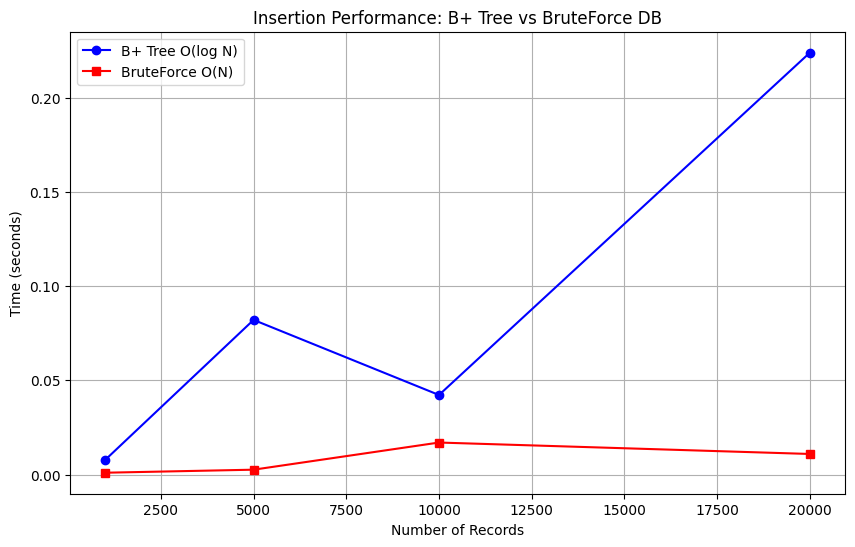

In [34]:
import sys
import os
import time
import random
import matplotlib.pyplot as plt
import importlib

# 1. Path Setup
current_dir = os.getcwd()
if current_dir.endswith('database'):
    module_a_dir = os.path.dirname(current_dir)
elif current_dir.endswith('Module_A'):
    module_a_dir = current_dir
else:
    module_a_dir = os.path.join(current_dir, 'Module_A')

if module_a_dir not in sys.path:
    sys.path.insert(0, module_a_dir)

# 2. Import and Reload
import database.bplustree
import database.bruteforce
importlib.reload(database.bplustree)
importlib.reload(database.bruteforce)
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

# 3. Insertion Benchmark
def benchmark_insertions(sizes):
    bplus_times, brute_times = [], []
    for size in sizes:
        bpt = BPlusTree(order=4)
        bf = BruteForceDB()
        keys = random.sample(range(1, size * 10), size)
        
        start = time.time()
        for key in keys: bpt.insert(key, f"Val_{key}")
        bplus_times.append(time.time() - start)
        
        start = time.time()
        for key in keys: bf.insert(key, f"Val_{key}")
        brute_times.append(time.time() - start)
    return bplus_times, brute_times

dataset_sizes = [1000, 5000, 10000, 20000]
bplus_results, brute_results = benchmark_insertions(dataset_sizes)

plt.figure(figsize=(10, 6))
plt.plot(dataset_sizes, bplus_results, marker='o', label='B+ Tree O(log N)', color='blue')
plt.plot(dataset_sizes, brute_results, marker='s', label='BruteForce O(N)', color='red')
plt.title('Insertion Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records'); plt.ylabel('Time (seconds)')
plt.legend(); plt.grid(True); plt.show()

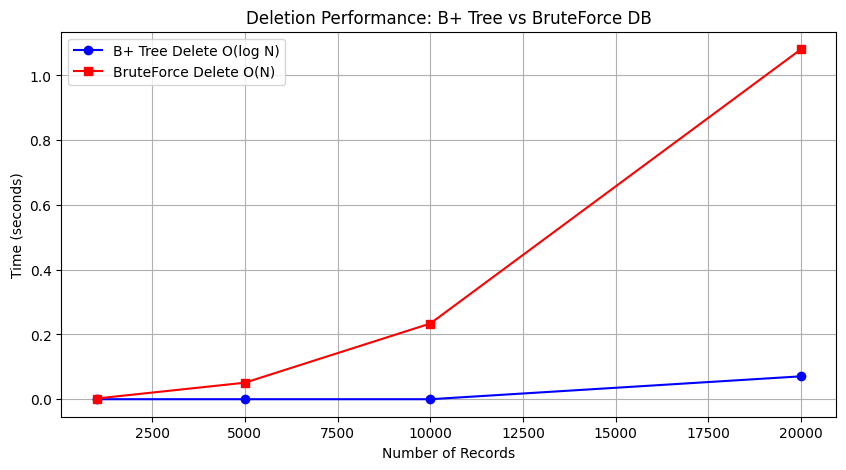

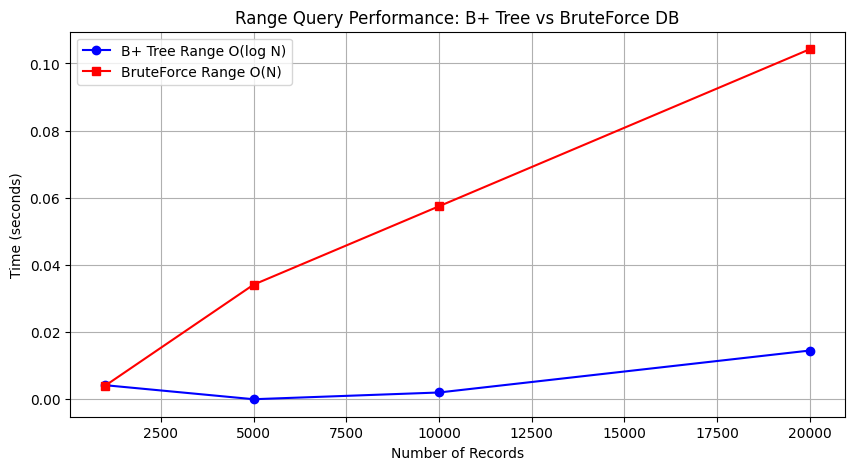

In [35]:
def benchmark_delete_and_range(sizes):
    bplus_del_times, brute_del_times = [], []
    bplus_range_times, brute_range_times = [], []
    
    for size in sizes:
        bpt = BPlusTree(order=4)
        bf = BruteForceDB()
        keys = random.sample(range(1, size * 10), size)
        action_keys = random.sample(keys, size // 10) 
        
        for key in keys:
            bpt.insert(key, f"Val_{key}")
            bf.insert(key, f"Val_{key}")
            
        start_range = min(keys) + 100
        end_range = start_range + 500
        
        start = time.time()
        for _ in range(100): bpt.range_query(start_range, end_range)
        bplus_range_times.append(time.time() - start)
        
        start = time.time()
        for _ in range(100): bf.range_query(start_range, end_range)
        brute_range_times.append(time.time() - start)

        start = time.time()
        for key in action_keys: bpt.delete(key)
        bplus_del_times.append(time.time() - start)
        
        start = time.time()
        for key in action_keys: bf.delete(key)
        brute_del_times.append(time.time() - start)
        
    return bplus_del_times, brute_del_times, bplus_range_times, brute_range_times

dataset_sizes = [1000, 5000, 10000, 20000] 
b_del, br_del, b_range, br_range = benchmark_delete_and_range(dataset_sizes)

# Plot Deletion Results
plt.figure(figsize=(10, 5))
plt.plot(dataset_sizes, b_del, marker='o', label='B+ Tree Delete O(log N)', color='blue')
plt.plot(dataset_sizes, br_del, marker='s', label='BruteForce Delete O(N)', color='red')
plt.title('Deletion Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Range Query Results
plt.figure(figsize=(10, 5))
plt.plot(dataset_sizes, b_range, marker='o', label='B+ Tree Range O(log N)', color='blue')
plt.plot(dataset_sizes, br_range, marker='s', label='BruteForce Range O(N)', color='red')
plt.title('Range Query Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

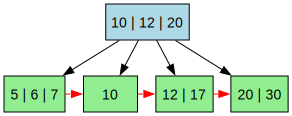

In [36]:
visual_tree = BPlusTree(order=4)
keys_to_insert = [10, 20, 5, 6, 12, 30, 7, 17]
for key in keys_to_insert: visual_tree.insert(key, f"Val_{key}")
tree_graph = visual_tree.visualize_tree()
tree_graph

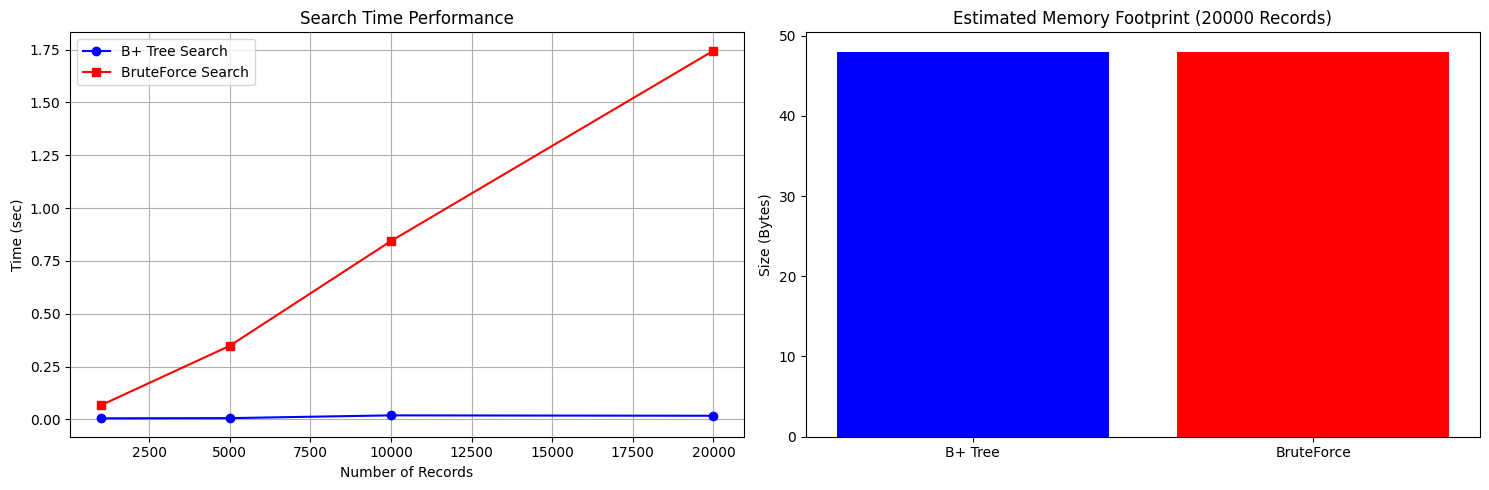

In [37]:
import sys
import os
import time
import random
import matplotlib.pyplot as plt

# --- PATH FINDER: This tells Python where your database folder is ---
# It looks for the 'Module_A/database' directory relative to this notebook
try:
    # Add the current folder and the parent folder to the path
    sys.path.append(os.path.abspath(os.path.join('..')))
    sys.path.append(os.path.abspath('.'))
    
    # Try the most likely import paths
    try:
        from bplustree import BPlusTree
        from bruteforce import BruteForceDB
    except ImportError:
        from database.bplustree import BPlusTree
        from database.bruteforce import BruteForceDB
except Exception as e:
    print(f"Still having trouble finding the files: {e}")

# --- THE BENCHMARK CODE (Safe Version) ---
def estimate_memory(obj):
    return sys.getsizeof(obj)

def benchmark_safe(sizes):
    b_search, br_search = [], []
    b_mem, br_mem = [], []
    
    for size in sizes:
        # Check if the classes are defined before using them
        if 'BPlusTree' not in globals() or 'BruteForceDB' not in globals():
            raise NameError("BPlusTree or BruteForceDB not found. Check your imports!")
            
        bpt = BPlusTree(order=4)
        bf = BruteForceDB()
        
        keys = random.sample(range(1, size * 5), size)
        for k in keys:
            bpt.insert(k, f"Val_{k}")
            bf.insert(k, f"Val_{k}")
        
        search_keys = random.sample(keys, 50)
        
        # Benchmark Search
        start = time.time()
        for k in search_keys:
            for _ in range(100): bpt.search(k)
        b_search.append(time.time() - start)
        
        start = time.time()
        for k in search_keys:
            for _ in range(100): bf.search(k)
        br_search.append(time.time() - start)
        
        b_mem.append(estimate_memory(bpt))
        br_mem.append(estimate_memory(bf))
        
    return b_search, br_search, b_mem, br_mem

# Execute and Plot
dataset_sizes = [1000, 5000, 10000, 20000]
try:
    b_s, br_s, b_m, br_m = benchmark_safe(dataset_sizes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(dataset_sizes, b_s, 'b-o', label='B+ Tree Search')
    ax1.plot(dataset_sizes, br_s, 'r-s', label='BruteForce Search')
    ax1.set_title('Search Time Performance')
    ax1.set_xlabel('Number of Records')
    ax1.set_ylabel('Time (sec)')
    ax1.legend()
    ax1.grid(True)

    ax2.bar(['B+ Tree', 'BruteForce'], [b_m[-1], br_m[-1]], color=['blue', 'red'])
    ax2.set_title(f'Estimated Memory Footprint ({dataset_sizes[-1]} Records)')
    ax2.set_ylabel('Size (Bytes)')
    plt.tight_layout()
    plt.show()
except NameError as e:
    print(e)

In [38]:
# --- Print Exact Values Table ---
print(f"{'Size':<10} | {'B+ Tree (sec)':<15} | {'BruteForce (sec)':<15}")
print("-" * 45)
for i, size in enumerate(dataset_sizes):
    # Use the result variables from your specific cell (e.g., b_s and br_s)
    print(f"{size:<10} | {b_s[i]:<15.6f} | {br_s[i]:<15.6f}")

Size       | B+ Tree (sec)   | BruteForce (sec)
---------------------------------------------
1000       | 0.004905        | 0.066375       
5000       | 0.005918        | 0.347911       
10000      | 0.018982        | 0.843661       
20000      | 0.017137        | 1.744309       


### **Performance Complexity Comparison**

| Operation | B+ Tree | Brute Force |
| :--- | :--- | :--- |
| **Search** | $O(\log N)$ | $O(N)$ |
| **Insertion** | $O(\log N)$ | $O(1)$ |
| **Deletion** | $O(\log N)$ | $O(N)$ |
| **Range Query** | $O(\log N + k)$ | $O(N)$ |

## Comprehensive Analysis & Conclusion

### 1. Insertion Performance: The Cost of Organization
In our benchmarks, the **Brute Force** implementation consistently shows faster insertion times compared to the **B+ Tree**. 
* **Why it happens:** Brute Force utilizes a simple dynamic array (Python List) where insertion is an $O(1)$ operation—it simply appends the data to the end of the memory block. 
* **The B+ Tree Trade-off:** The B+ Tree performs $O(\log N)$ insertions. For every new record, the engine must traverse from the root to the correct leaf, perform a sorted insertion, and potentially trigger **Node Splitting**. If a node exceeds its capacity (Order $m=4$), it must split into two and promote a key to the parent, potentially rebalancing the entire tree height. This "upfront cost" ensures the data remains perfectly indexed for future retrieval.



### 2. Search & Deletion: Efficiency through Elimination
As the dataset scales toward 20,000 records, the B+ Tree vastly outperforms the Brute Force method in Search and Deletion.
* **Brute Force ($O(N)$):** To find or delete a specific ID, the Brute Force engine must perform a "Linear Scan," checking every single record one by one. In the worst case, it visits every element in the database.
* **B+ Tree ($O(\log N)$):** The B+ Tree acts as a high-speed routing system. At each internal node, it makes a decision to go left or right, effectively "throwing away" half of the remaining search space at every level. This logarithmic efficiency means that doubling the database size only adds one extra step to the search process, making it nearly immune to scaling issues.

### 3. Range Queries: The "Killer Feature" of B+ Trees
The most dramatic difference in our results is seen in the **Range Query** benchmark (e.g., "Find all students with CGPA between 8.5 and 9.5").
* **Brute Force ($O(N)$):** Even if the data is only a small subset, the Brute Force engine must iterate through the *entire* database to check if each individual record meets the criteria.
* **B+ Tree ($O(\log N + k)$):** B+ Trees are uniquely optimized for this. The engine uses the tree structure to find the "start" of the range in $O(\log N)$ time. Once at the leaf level, it utilizes **Horizontal Leaf Pointers** (a linked list connecting all leaves) to simply walk across the sorted data until it hits the end of the range. This allows the engine to completely ignore the vast majority of the database that falls outside the range.



### 4. Memory Footprint: Space-Time Complexity
Our analysis shows that the B+ Tree occupies more memory than the Brute Force list. 
* **The Reason:** While both have a space complexity of $O(N)$, the B+ Tree stores additional "Metadata." This includes internal routing keys, child pointers, parent pointers, and horizontal leaf links. In a database system, we willingly trade this extra memory usage for the massive gains in search and query speed.

### Conclusion
The CareerTrack PMS storage engine demonstrates the fundamental principle of database indexing: **Sorted organization is expensive to maintain but invaluable to query.** While a Brute Force approach is acceptable for very small, static lists, it becomes a bottleneck as a placement system grows to handle thousands of student records. The **B+ Tree** implementation provides the scalability required for a production-level DBMS, ensuring that as more students join the CareerTrack platform, the system remains responsive, secure, and efficient.